In [ ]:
import optics_design_workbench.jupyter_utils as opw
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# select most recent raw data subfolder
raw = opw.latestRawFolder()

In [3]:
# load all hit files if the simulation run
hits = raw.loadHits()

[Optics Design 14:40:31.428158] finding all result files in ./GettingStarted.OpticsDesign/raw/simulation-run-000000/**/*-hits.pkl


In [8]:
# calculate 2D histogram of hits
histogram = hits.histogram()

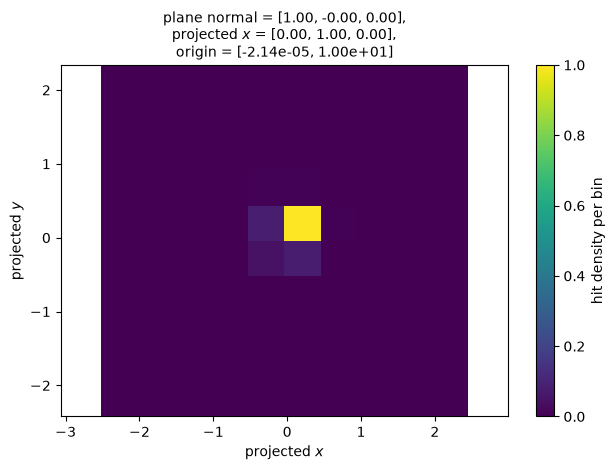

In [9]:
# plot the histogram
histogram.plot()

In [18]:
# calculate 2D histogram of hits with way more bins
histogram = hits.histogram(bins=np.linspace(-.05, .05, 100))

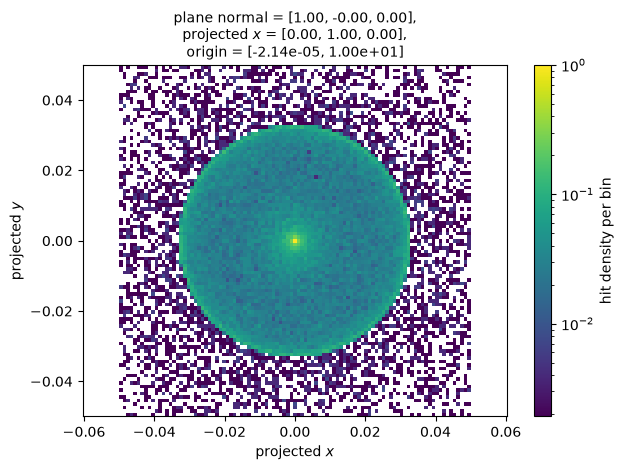

In [ ]:
# plot the histogram with logarithmic color scale
histogram.plot(norm=mpl.colors.LogNorm())
plt.savefig('spot-shape-histogram.jpg')

In [175]:
# obtain polar coordinate histogram, choose pi/2
# bin steps in azimuthal angle and 500 bins in
# the radial direction.
polarHist = hits.histogram(
      binCoords='polar', 
      bins=[np.arange(0, 2*np.pi, np.pi/2), 
            np.linspace(0, .05, 500)])

/tmp/ipykernel_695706/2807693257.py:9: RuntimeWarning: divide by zero encountered in log
  a, b = np.polyfit(np.log(r)[:10], np.log(dens)[:10], deg=1)


Text(0, 0.5, 'power density')

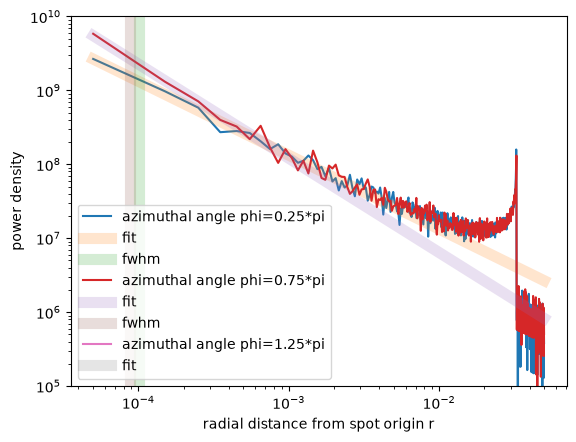

In [201]:
# loop through azimuth angles if histogram
phis, r, hists = polarHist.byAzimuth()
for phi, dens in zip(phis, hists):
  
  # plot simulated density
  plt.plot(r, dens, label=f'azimuthal angle phi={phi/np.pi:.2f}*pi')
  
  # perform and plot line fit of loglog data
  a, b = np.polyfit(np.log(r)[:10], np.log(dens)[:10], deg=1)
  rFit = np.geomspace(min(r), max(r), 100)
  fitDens = np.exp( a*np.log(rFit)+b )
  plt.plot(rFit, fitDens, lw=8, alpha=.2, label='fit')
  
  # calculate, plot and store fwhm from fit in list
  try:
    fwhm = min(rFit[fitDens<=max(fitDens)/2])
    plt.plot([fwhm]*2, [1e5, 1e10], lw=8, alpha=.2, label='fwhm')
  # silently ignore errors in cases where fwhm is ill defined
  except ValueError:
    pass
  
plt.legend()
plt.loglog()
plt.ylim(1e5, 1e10)
plt.xlabel('radial distance from spot origin r')
plt.ylabel('power density')